# Bayesian Spatial Panel Models and Diagnostics

This notebook demonstrates the panel-model classes in `bayespecon`:
- Fixed effects / pooled panel models: `OLSPanelFE`, `SARPanelFE`, `SEMPanelFE`, `SDMPanelFE`, `SDEMPanelFE`
- Random effects panel models: `OLSPanelRE`, `SARPanelRE`, `SEMPanelRE`

It also demonstrates diagnostics inspired by the MATLAB reference code:
- `rdiagnose`-style influence diagnostics
- Breusch-Pagan test
- ARCH test
- Ljung-Box Q test
- Panel-specific diagnostics (`panel_residual_structure`, `pesaran_cd_test`)

## Panel Model Equations

Let observations be stacked by time, then unit (panel_g convention).

Fixed-effects / pooled classes:
- OLS panel: $y_{it} = x_{it}'\beta + a_i + \tau_t + \epsilon_{it}$
- SAR panel: $y_{it} = \rho (Wy)_{it} + x_{it}'\beta + a_i + \tau_t + \epsilon_{it}$
- SEM panel: $y_{it} = x_{it}'\beta + a_i + \tau_t + u_{it},\; u_{it}=\lambda (Wu)_{it}+\epsilon_{it}$
- SDM panel: $y_{it} = \rho (Wy)_{it} + x_{it}'\beta + (Wx)_{it}'\theta + a_i + \tau_t + \epsilon_{it}$
- SDEM panel: $y_{it} = x_{it}'\beta + (Wx)_{it}'\theta + a_i + \tau_t + u_{it},\; u_{it}=\lambda (Wu)_{it}+\epsilon_{it}$

Random-effects classes:
- OLS random effects: $y_{it} = x_{it}'\beta + \alpha_i + \epsilon_{it},\; \alpha_i \sim N(0, \sigma_\alpha^2)$
- SAR random effects: $y_{it} = \rho (Wy)_{it} + x_{it}'\beta + \alpha_i + \epsilon_{it},\; \alpha_i \sim N(0, \sigma_\alpha^2)$
- SEM random effects: $y_{it} = x_{it}'\beta + \alpha_i + u_{it},\; u_{it}=\lambda (Wu)_{it}+\epsilon_{it},\; \alpha_i \sim N(0, \sigma_\alpha^2)$

The `model` argument selects the pooled or fixed-effects specification for the FE classes:
- `0` pooled
- `1` unit FE
- `2` time FE
- `3` two-way FE

The RE classes are hierarchical models with unit-level random intercepts, so they internally use the pooled design and estimate `sigma_alpha` directly.

In [ ]:
import pathlib
import sys

import arviz as az
import geodatasets
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from libpysal.graph import Graph

repo_root = pathlib.Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from bayespecon import (
    OLSPanelFE,
    OLSPanelRE,
    SARPanelFE,
    SARPanelRE,
    SDEMPanelFE,
    SDMPanelFE,
    SEMPanelFE,
    SEMPanelRE,
)

az.style.use("arviz-white")

## Build a Balanced Panel Dataset

The source data are cross-sectional (`geoda.airbnb`).
For pedagogy, we synthesize a balanced panel by replicating units across time with small shocks and drift.

In [2]:
gdf = gpd.read_file(geodatasets.data.geoda.airbnb.url)
xcols = ["poverty", "rev_rating", "num_spots", "crowded"]
ycol = "price_pp"
gdf = gdf.dropna(subset=xcols + [ycol]).copy().reset_index(drop=True)

N = len(gdf)
T = 4
rng = np.random.default_rng(2026)

panel_parts = []
for t in range(T):
    d = gdf.copy()
    d["unit"] = np.arange(N)
    d["time"] = t

    # Add mild temporal dynamics for demonstration.
    d["price_pp"] = d["price_pp"] * (1.0 + 0.03 * t) + rng.normal(0, 0.8, size=N)
    d["rev_rating"] = d["rev_rating"] + 0.02 * t + rng.normal(0, 0.02, size=N)

    panel_parts.append(d)

panel = pd.concat(panel_parts, axis=0).sort_values(["time", "unit"]).reset_index(drop=True)
W = Graph.build_contiguity(gdf, rook=False).transform('r')

print(f"Balanced panel: N={N}, T={T}, observations={len(panel)}")
display(panel[["time", "unit", ycol] + xcols].head())

Balanced panel: N=67, T=4, observations=268


,time,unit,price_pp,poverty,rev_rating,num_spots,crowded
0,0,0,77.523397,29.6,87.782920,38,1.8
1,0,1,53.967457,39.7,88.788162,20,1.3
2,0,2,82.482939,51.2,91.753393,6,3.2
3,0,3,120.649950,29.3,92.715184,30,3.3
4,0,4,78.502089,21.7,90.642275,39,2.4


## Shared Helpers

In [3]:
def fit_panel_model(model_cls, formula, data, W, model=3, draws=300, tune=300, chains=2, seed=42):
    m = model_cls(
        formula=formula,
        data=data,
        W=W,
        unit_col="unit",
        time_col="time",
        model=model,
        logdet_method="auto",
    )

    idata = m.fit(
        draws=draws,
        tune=tune,
        chains=chains,
        target_accept=0.9,
        random_seed=seed,
        progressbar=False,
        idata_kwargs={"log_likelihood": True},
    )

    summary = m.summary(round_to=3)
    effects = m.spatial_effects()
    effects_df = pd.DataFrame({
        "feature": effects["feature_names"],
        "direct": effects["direct"],
        "indirect": effects["indirect"],
        "total": effects["total"],
    })

    return m, idata, summary, effects_df


def diagnostics_table(idata, var_names):
    cols = ["mean", "sd", "ess_bulk", "ess_tail", "r_hat"]
    return az.summary(idata, var_names=var_names, round_to=3)[cols]


def show_trace(idata, var_names, title):
    az.plot_trace(idata, var_names=var_names)
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

## Fit: OLSPanelFE

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, sigma]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-12531.993,963055.629,-1884635.802,1800448.655,36461.097,38138.973,693.993,482.439,1.015
poverty,1039.423,1009066.112,-1843276.367,1783362.997,33646.400,38372.814,905.154,456.723,1.002
rev_rating,-1.195,4.228,-9.296,6.544,0.162,0.169,748.697,441.008,0.999
num_spots,1564.568,1012440.212,-1761122.227,1949067.915,32706.200,34017.746,948.290,446.547,1.000
crowded,28965.724,1028139.420,-1862548.510,1839357.771,42425.869,39850.481,577.439,492.911,1.005
sigma,1.349,0.058,1.239,1.458,0.002,0.003,672.293,228.089,0.999


,feature,direct,indirect,total
0,Intercept,-12531.993093,0.0,-12531.993093
1,poverty,1039.423424,0.0,1039.423424
2,rev_rating,-1.194691,0.0,-1.194691
3,num_spots,1564.568307,0.0,1564.568307
4,crowded,28965.724232,0.0,28965.724232


,mean,sd,ess_bulk,ess_tail,r_hat
beta[Intercept],-12531.993,963055.629,693.993,482.439,1.015
beta[poverty],1039.423,1009066.112,905.154,456.723,1.002
beta[rev_rating],-1.195,4.228,748.697,441.008,0.999
beta[num_spots],1564.568,1012440.212,948.290,446.547,1.000
beta[crowded],28965.724,1028139.420,577.439,492.911,1.005
sigma,1.349,0.058,672.293,228.089,0.999


/var/folders/j8/5bgcw6hs7cqcbbz48d6bsftw0000gp/T/ipykernel_74921/2150201610.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


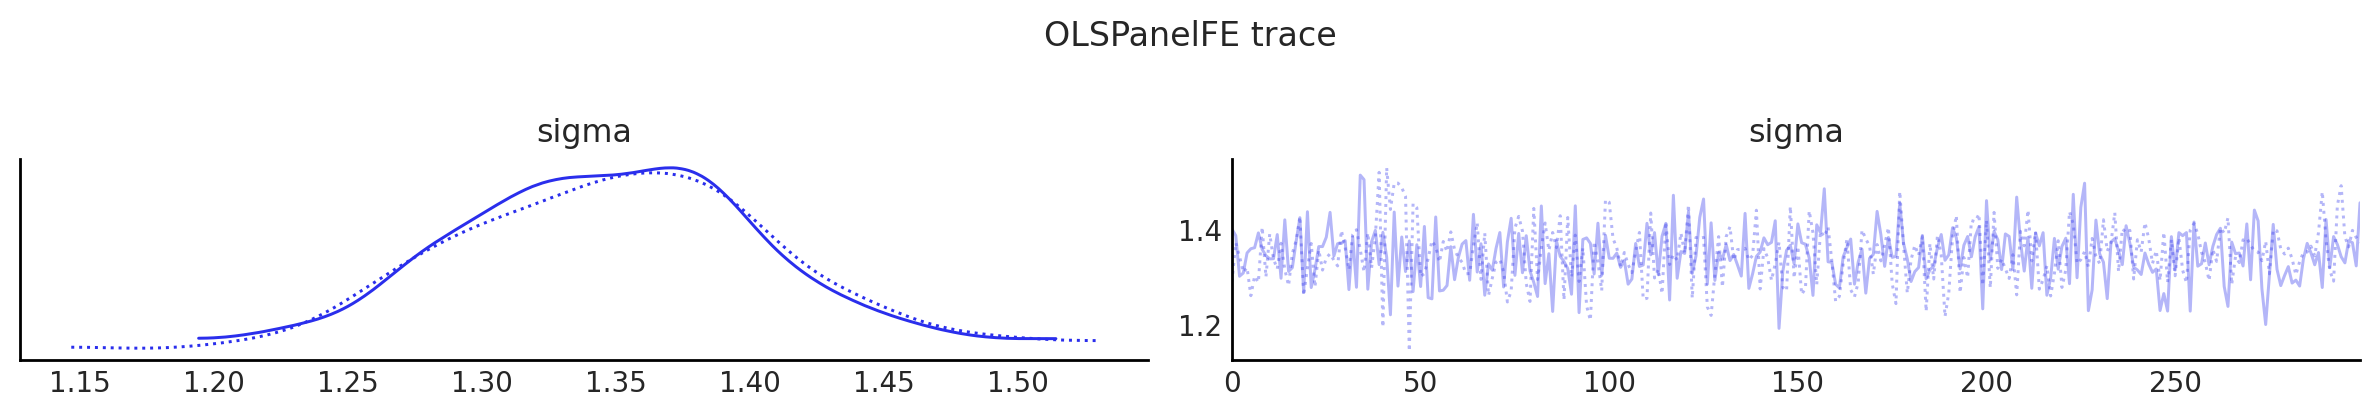

In [4]:
formula = "price_pp ~ poverty + rev_rating + num_spots + crowded"
ols_panel, idata_ols, summary_ols, effects_ols = fit_panel_model(
    OLSPanelFE, formula, panel, W, model=3
)
display(summary_ols)
display(effects_ols)
display(diagnostics_table(idata_ols, ["beta", "sigma"]))
show_trace(idata_ols, ["sigma"], "OLSPanelFE trace")

## Fit: SARPanelFE

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-6478.575,970297.368,-2087321.550,1611649.815,28613.804,38612.319,1146.472,469.494,0.999
poverty,-43863.992,1060333.401,-1915734.678,2034953.394,34016.651,50178.185,993.582,338.071,1.000
rev_rating,0.327,3.586,-6.304,7.164,0.121,0.144,876.026,503.671,1.000
num_spots,-29177.237,1047578.274,-1860417.048,1975315.482,32039.358,59643.417,1053.822,454.623,1.003
crowded,6386.480,962089.762,-1581517.040,1982416.879,27749.293,39079.543,1207.564,474.363,1.004
rho,0.549,0.057,0.444,0.651,0.002,0.002,1077.177,506.195,1.006
sigma,1.159,0.053,1.069,1.263,0.002,0.002,1175.236,373.794,1.001


,feature,direct,indirect,total
0,Intercept,-7078.002241,7024.380812,-53.621430
1,poverty,-47922.485851,47559.435358,-363.050493
2,rev_rating,0.357337,-0.354630,0.002707
3,num_spots,-31876.846673,31635.354507,-241.492166
4,crowded,6977.385315,-6924.526138,52.859177


,mean,sd,ess_bulk,ess_tail,r_hat
rho,0.549,0.057,1077.177,506.195,1.006
beta[Intercept],-6478.575,970297.368,1146.472,469.494,0.999
beta[poverty],-43863.992,1060333.401,993.582,338.071,1.000
beta[rev_rating],0.327,3.586,876.026,503.671,1.000
beta[num_spots],-29177.237,1047578.274,1053.822,454.623,1.003
beta[crowded],6386.480,962089.762,1207.564,474.363,1.004
sigma,1.159,0.053,1175.236,373.794,1.001


/var/folders/j8/5bgcw6hs7cqcbbz48d6bsftw0000gp/T/ipykernel_74921/2150201610.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


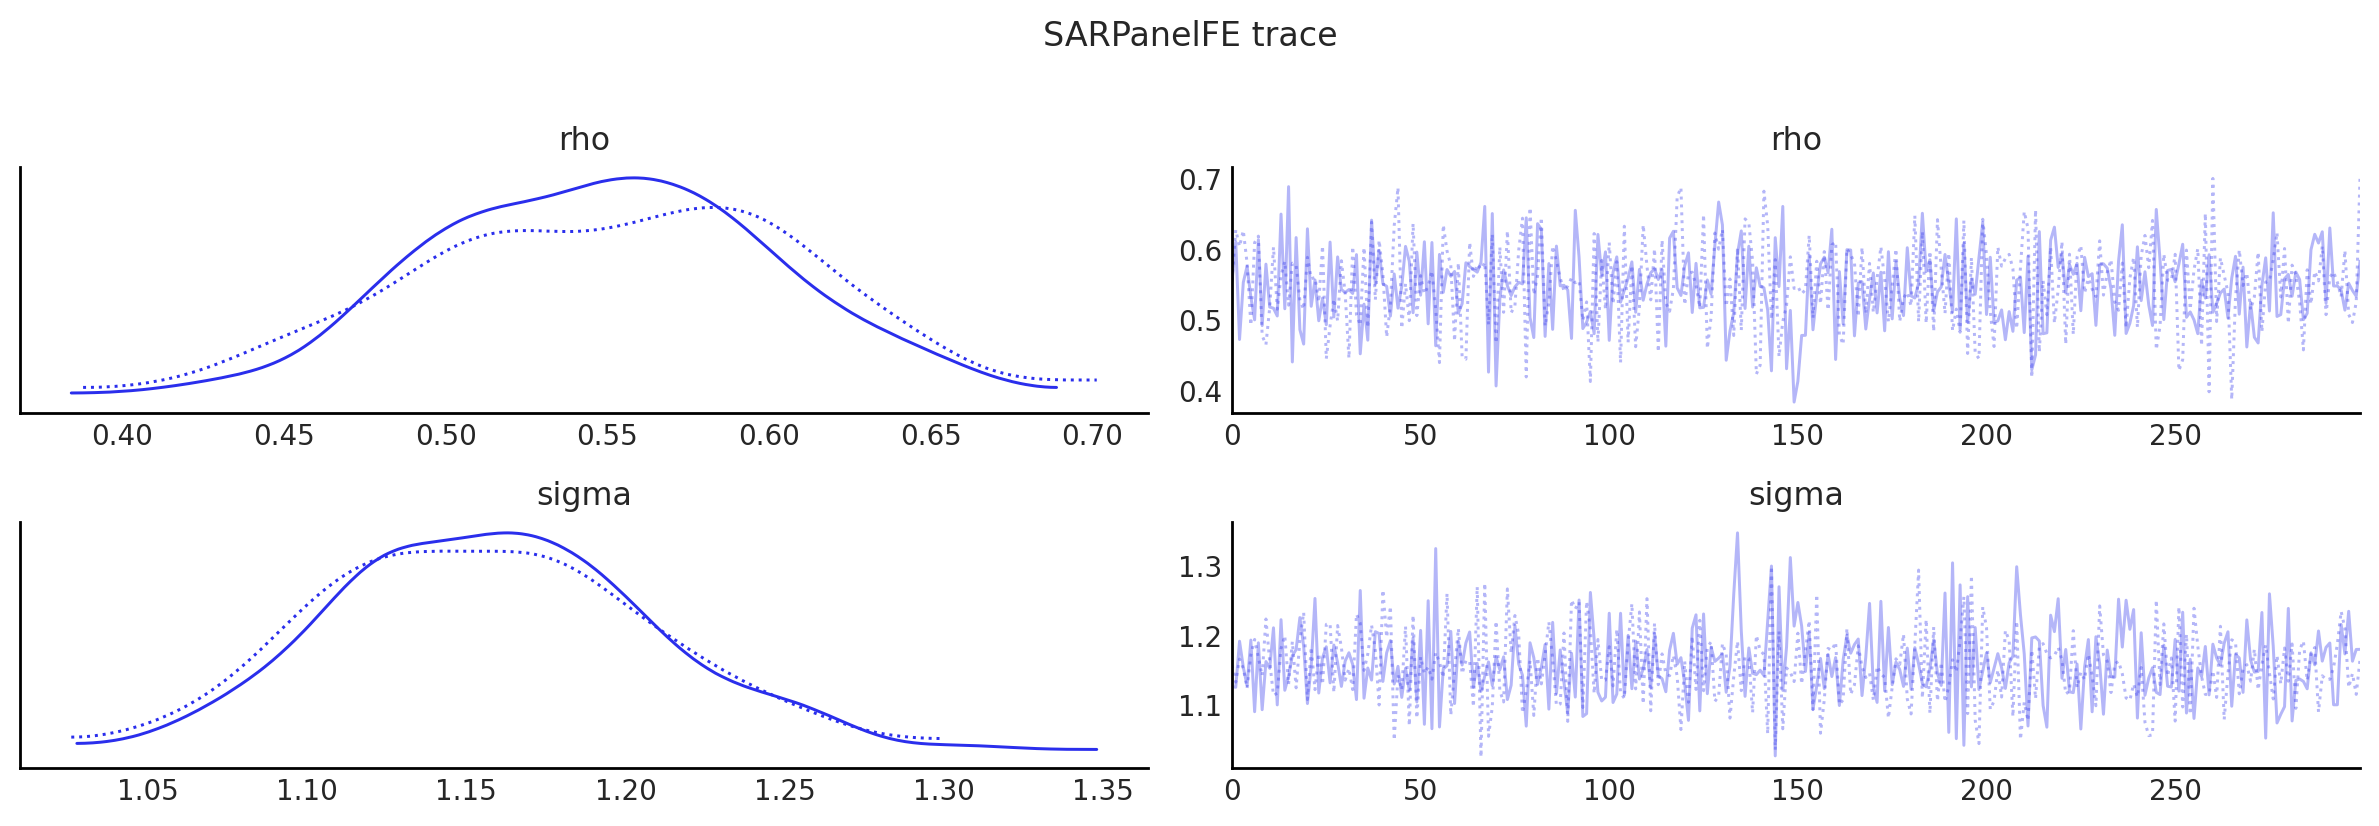

In [5]:
sar_panel, idata_sar, summary_sar, effects_sar = fit_panel_model(
    SARPanelFE, formula, panel, W, model=3
)
display(summary_sar)
display(effects_sar)
display(diagnostics_table(idata_sar, ["rho", "beta", "sigma"]))
show_trace(idata_sar, ["rho", "sigma"], "SARPanelFE trace")

## Fit: SEMPanelFE

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [lam, beta, sigma]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,22578.347,992465.980,-1922660.890,1834422.432,29217.056,44752.947,1154.119,406.693,1.005
poverty,-2537.689,1069805.015,-1939838.723,2005702.554,30306.993,46862.846,1252.214,418.956,1.000
rev_rating,1.067,3.772,-6.103,7.779,0.124,0.159,938.930,483.505,1.002
num_spots,-26733.693,1008807.681,-1851305.968,1770706.666,30242.536,38374.284,1127.681,422.609,1.000
crowded,-21344.521,1046114.971,-1899891.933,1869356.522,32713.967,41779.679,1006.325,437.187,0.999
lam,0.550,0.057,0.455,0.661,0.002,0.003,1000.543,542.947,1.001
sigma,1.159,0.052,1.068,1.267,0.002,0.002,906.529,495.591,1.008


,feature,direct,indirect,total
0,Intercept,22578.347442,0.0,22578.347442
1,poverty,-2537.688845,0.0,-2537.688845
2,rev_rating,1.066520,0.0,1.066520
3,num_spots,-26733.692949,0.0,-26733.692949
4,crowded,-21344.521089,0.0,-21344.521089


,mean,sd,ess_bulk,ess_tail,r_hat
lam,0.550,0.057,1000.543,542.947,1.001
beta[Intercept],22578.347,992465.980,1154.119,406.693,1.005
beta[poverty],-2537.689,1069805.015,1252.214,418.956,1.000
beta[rev_rating],1.067,3.772,938.930,483.505,1.002
beta[num_spots],-26733.693,1008807.681,1127.681,422.609,1.000
beta[crowded],-21344.521,1046114.971,1006.325,437.187,0.999
sigma,1.159,0.052,906.529,495.591,1.008


/var/folders/j8/5bgcw6hs7cqcbbz48d6bsftw0000gp/T/ipykernel_74921/2150201610.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


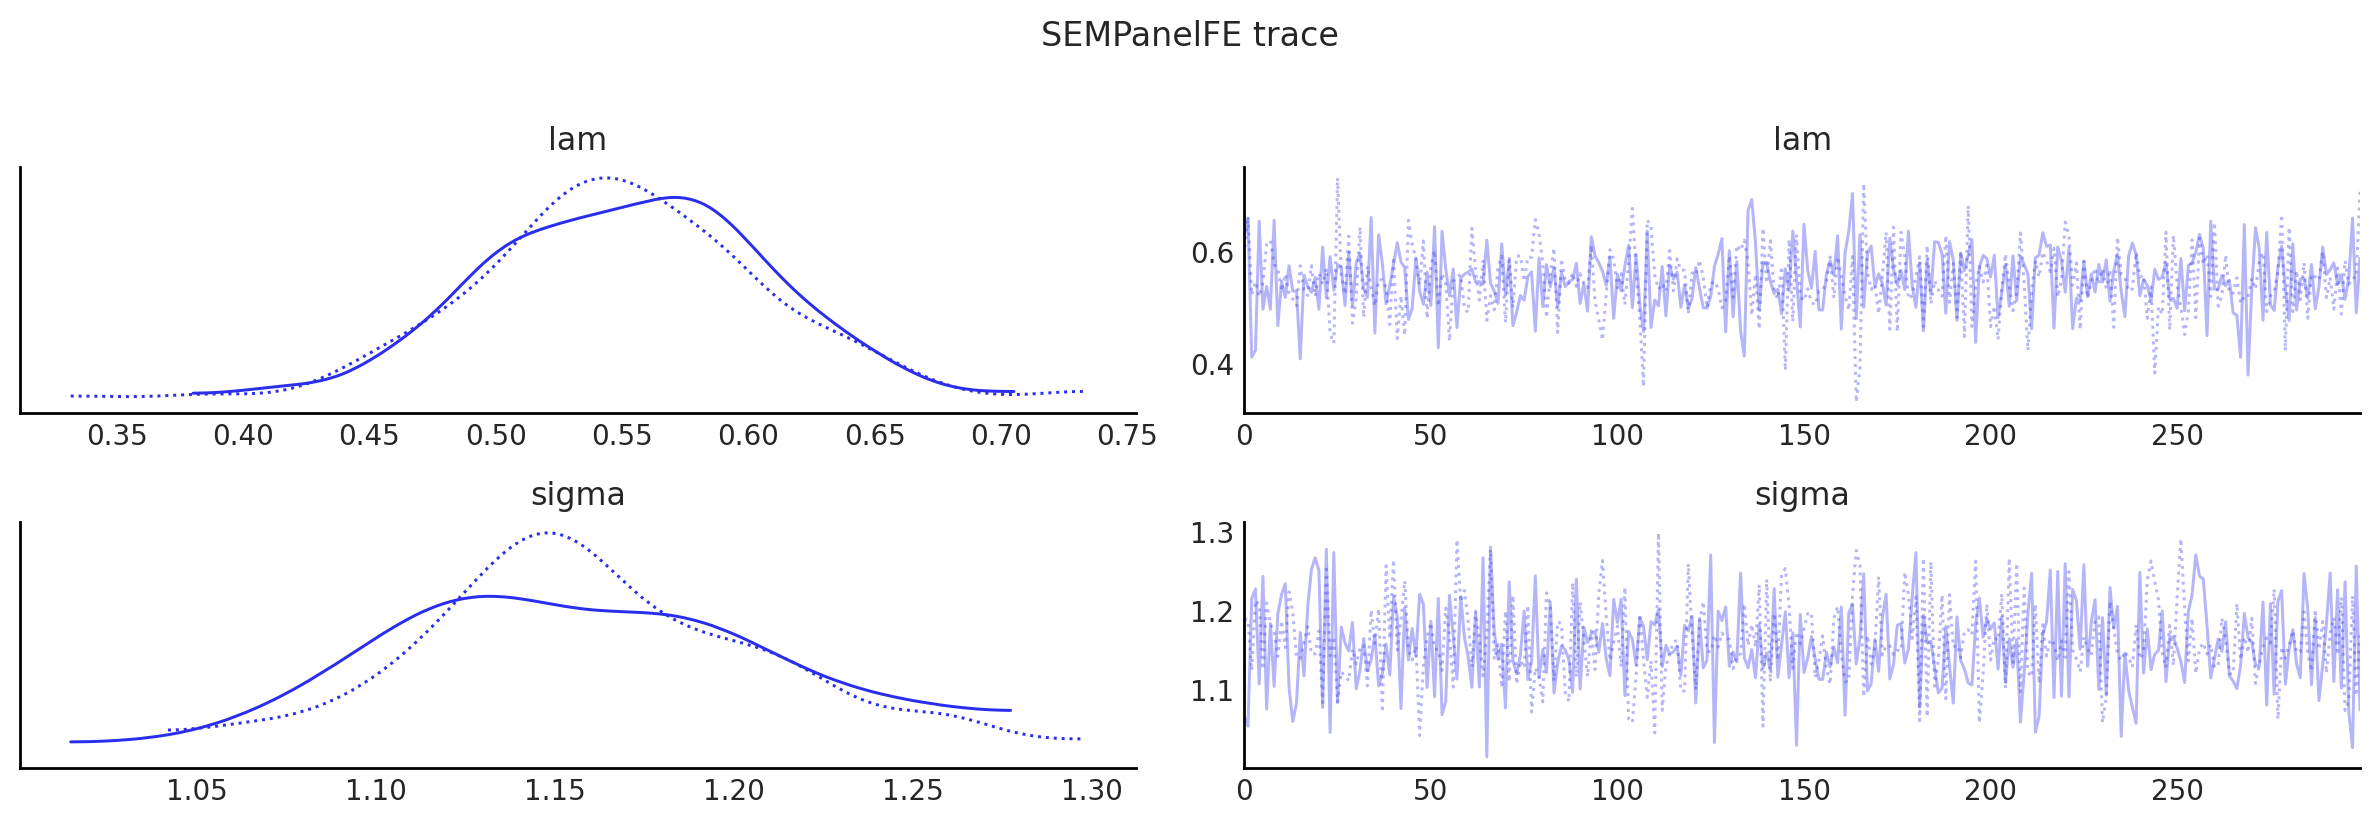

In [6]:
sem_panel, idata_sem, summary_sem, effects_sem = fit_panel_model(
    SEMPanelFE, formula, panel, W, model=3
)
display(summary_sem)
display(effects_sem)
display(diagnostics_table(idata_sem, ["lam", "beta", "sigma"]))
show_trace(idata_sem, ["lam", "sigma"], "SEMPanelFE trace")

## Fit: SDMPanelFE

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,11512.526,997236.808,-1918501.034,1676936.014,32565.495,45773.792,920.360,354.477,1.004
poverty,-24272.856,1005675.298,-1697849.833,2037852.101,29469.888,47727.211,1129.935,406.098,1.003
rev_rating,0.300,4.353,-8.453,8.463,0.128,0.205,1218.638,341.021,1.006
num_spots,6871.712,978897.737,-1813596.392,1888943.403,29658.617,45115.575,1155.663,457.446,1.003
crowded,3654.130,1042253.679,-1777408.918,2131138.954,29481.145,48925.597,1255.526,415.634,1.013
W*poverty,-21997.447,974251.754,-2075379.868,1564340.020,30669.879,46960.294,1009.906,319.336,1.002
W*rev_rating,-4.675,8.011,-18.802,10.353,0.198,0.306,1459.881,394.155,1.000
W*num_spots,17454.552,1012743.465,-1803298.535,1891149.815,29024.499,47671.852,1211.297,450.090,1.011
W*crowded,16308.673,998897.458,-1798178.514,1935409.231,31956.557,41697.394,982.086,372.822,1.003
rho,0.547,0.061,0.420,0.654,0.002,0.003,870.803,389.688,0.998


,feature,direct,indirect,total
0,poverty,-30175.423095,29794.402965,-381.020131
1,rev_rating,-0.454867,0.418837,-0.036030
2,num_spots,10421.541430,-10221.222962,200.318468
3,crowded,6717.737932,-6553.351068,164.386864


,mean,sd,ess_bulk,ess_tail,r_hat
rho,0.547,0.061,870.803,389.688,0.998
beta[Intercept],11512.526,997236.808,920.360,354.477,1.004
beta[poverty],-24272.856,1005675.298,1129.935,406.098,1.003
beta[rev_rating],0.300,4.353,1218.638,341.021,1.006
beta[num_spots],6871.712,978897.737,1155.663,457.446,1.003
beta[crowded],3654.130,1042253.679,1255.526,415.634,1.013
beta[W*poverty],-21997.447,974251.754,1009.906,319.336,1.002
beta[W*rev_rating],-4.675,8.011,1459.881,394.155,1.000
beta[W*num_spots],17454.552,1012743.465,1211.297,450.090,1.011
beta[W*crowded],16308.673,998897.458,982.086,372.822,1.003


/var/folders/j8/5bgcw6hs7cqcbbz48d6bsftw0000gp/T/ipykernel_51752/2150201610.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


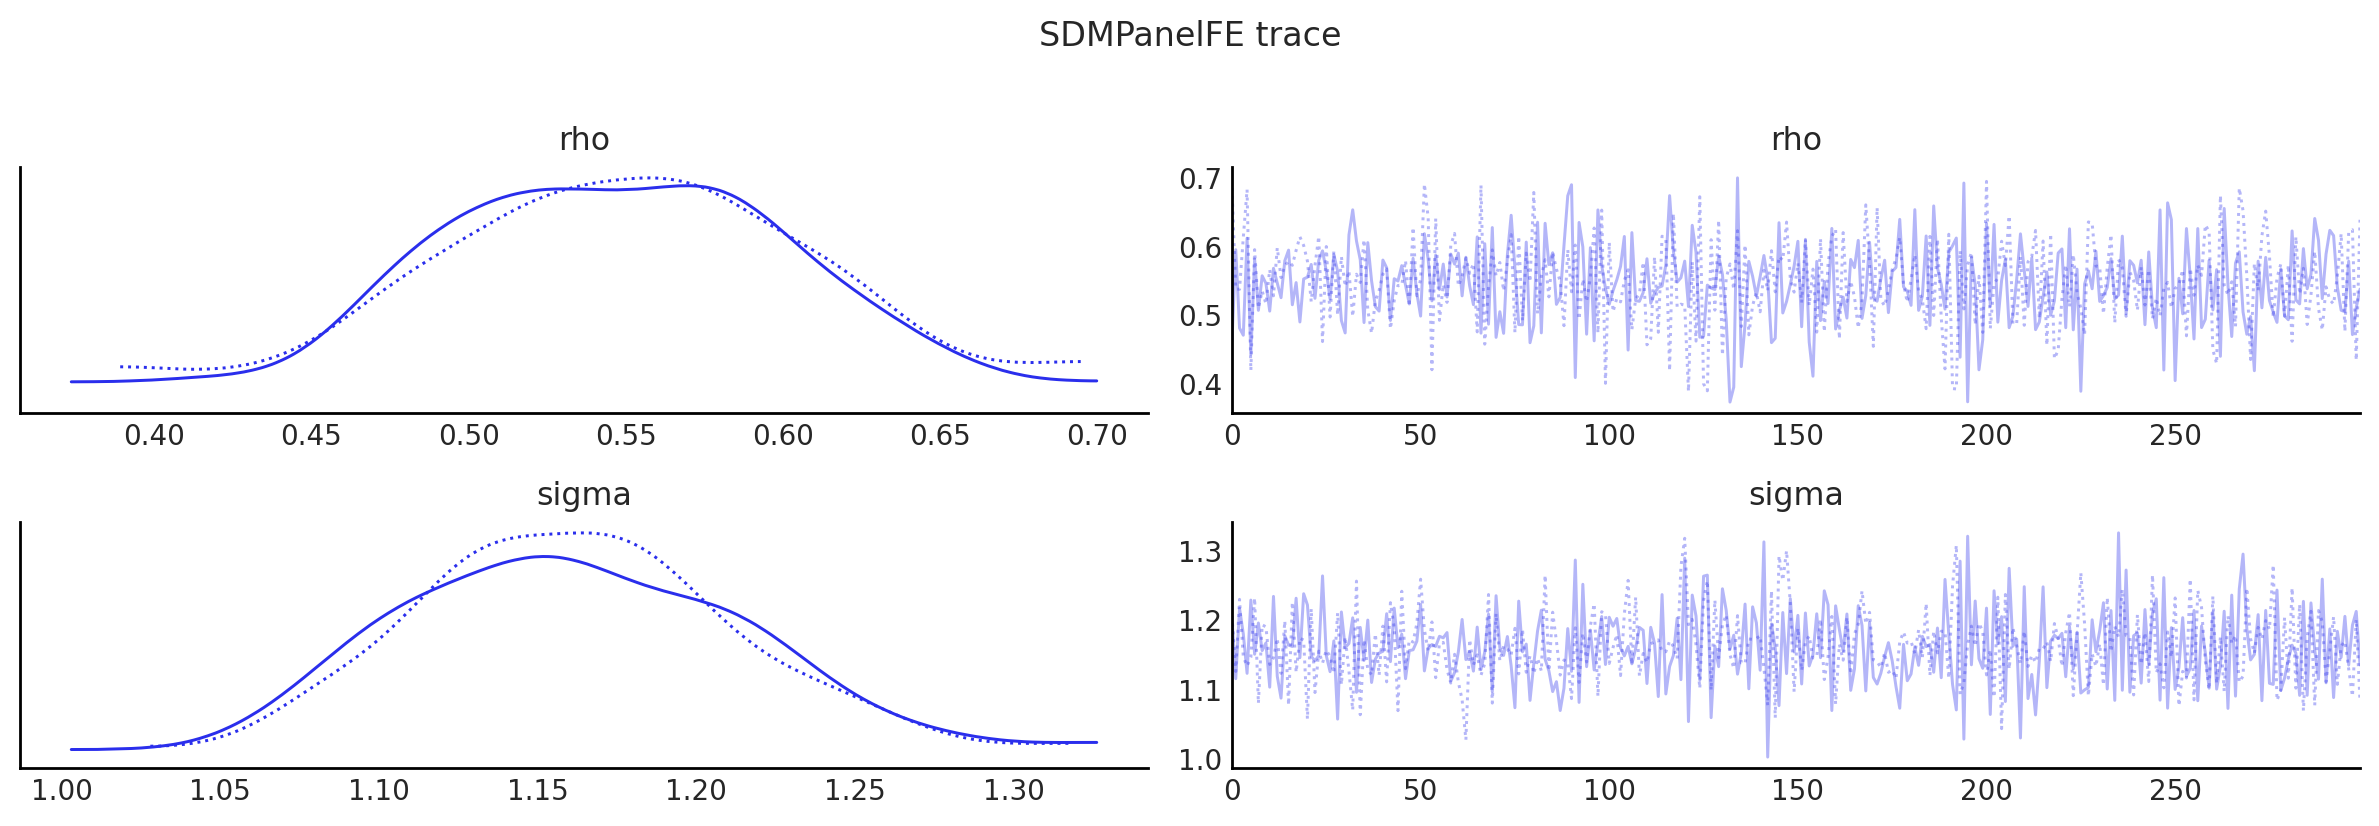

In [16]:
sdm_panel, idata_sdm, summary_sdm, effects_sdm = fit_panel_model(
    SDMPanelFE, formula, panel, W, model=3
)
display(summary_sdm)
display(effects_sdm)
display(diagnostics_table(idata_sdm, ["rho", "beta", "sigma"]))
show_trace(idata_sdm, ["rho", "sigma"], "SDMPanelFE trace")

## Fit: SDEMPanelFE

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [lam, beta, sigma]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-31078.220,964547.679,-1819584.964,1651652.725,30100.770,42610.543,1062.971,414.029,1.013
poverty,-15509.537,1021202.222,-1849972.234,1901633.098,27949.714,34538.803,1287.649,520.110,1.004
rev_rating,1.229,4.470,-6.533,9.994,0.187,0.151,581.094,450.391,1.006
num_spots,-7641.255,995907.960,-1733678.064,1874241.232,29435.325,40719.975,1145.509,511.673,1.000
crowded,-22014.406,1074339.617,-1874619.499,2190430.265,30344.389,53393.313,1268.212,411.487,1.002
W*poverty,-78776.006,946958.653,-1737126.327,1749039.837,27509.929,44263.371,1144.461,439.791,1.003
W*rev_rating,0.514,9.825,-17.245,18.607,0.380,0.369,678.258,443.419,1.011
W*num_spots,-46796.665,1001750.488,-1984894.387,1702202.304,29799.160,48125.529,1139.781,379.597,1.000
W*crowded,-63557.724,1011244.634,-1791283.796,1918099.363,31123.323,57270.162,1025.565,409.998,0.999
lam,0.555,0.059,0.453,0.674,0.002,0.002,1293.155,480.847,0.999


,feature,direct,indirect,total
0,poverty,-15509.536591,-78776.005658,-94285.542248
1,rev_rating,1.228644,0.514218,1.742862
2,num_spots,-7641.254940,-46796.664510,-54437.919449
3,crowded,-22014.405733,-63557.723957,-85572.129690


,mean,sd,ess_bulk,ess_tail,r_hat
lam,0.555,0.059,1293.155,480.847,0.999
beta[Intercept],-31078.220,964547.679,1062.971,414.029,1.013
beta[poverty],-15509.537,1021202.222,1287.649,520.110,1.004
beta[rev_rating],1.229,4.470,581.094,450.391,1.006
beta[num_spots],-7641.255,995907.960,1145.509,511.673,1.000
beta[crowded],-22014.406,1074339.617,1268.212,411.487,1.002
beta[W*poverty],-78776.006,946958.653,1144.461,439.791,1.003
beta[W*rev_rating],0.514,9.825,678.258,443.419,1.011
beta[W*num_spots],-46796.665,1001750.488,1139.781,379.597,1.000
beta[W*crowded],-63557.724,1011244.634,1025.565,409.998,0.999


/var/folders/j8/5bgcw6hs7cqcbbz48d6bsftw0000gp/T/ipykernel_51752/2150201610.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


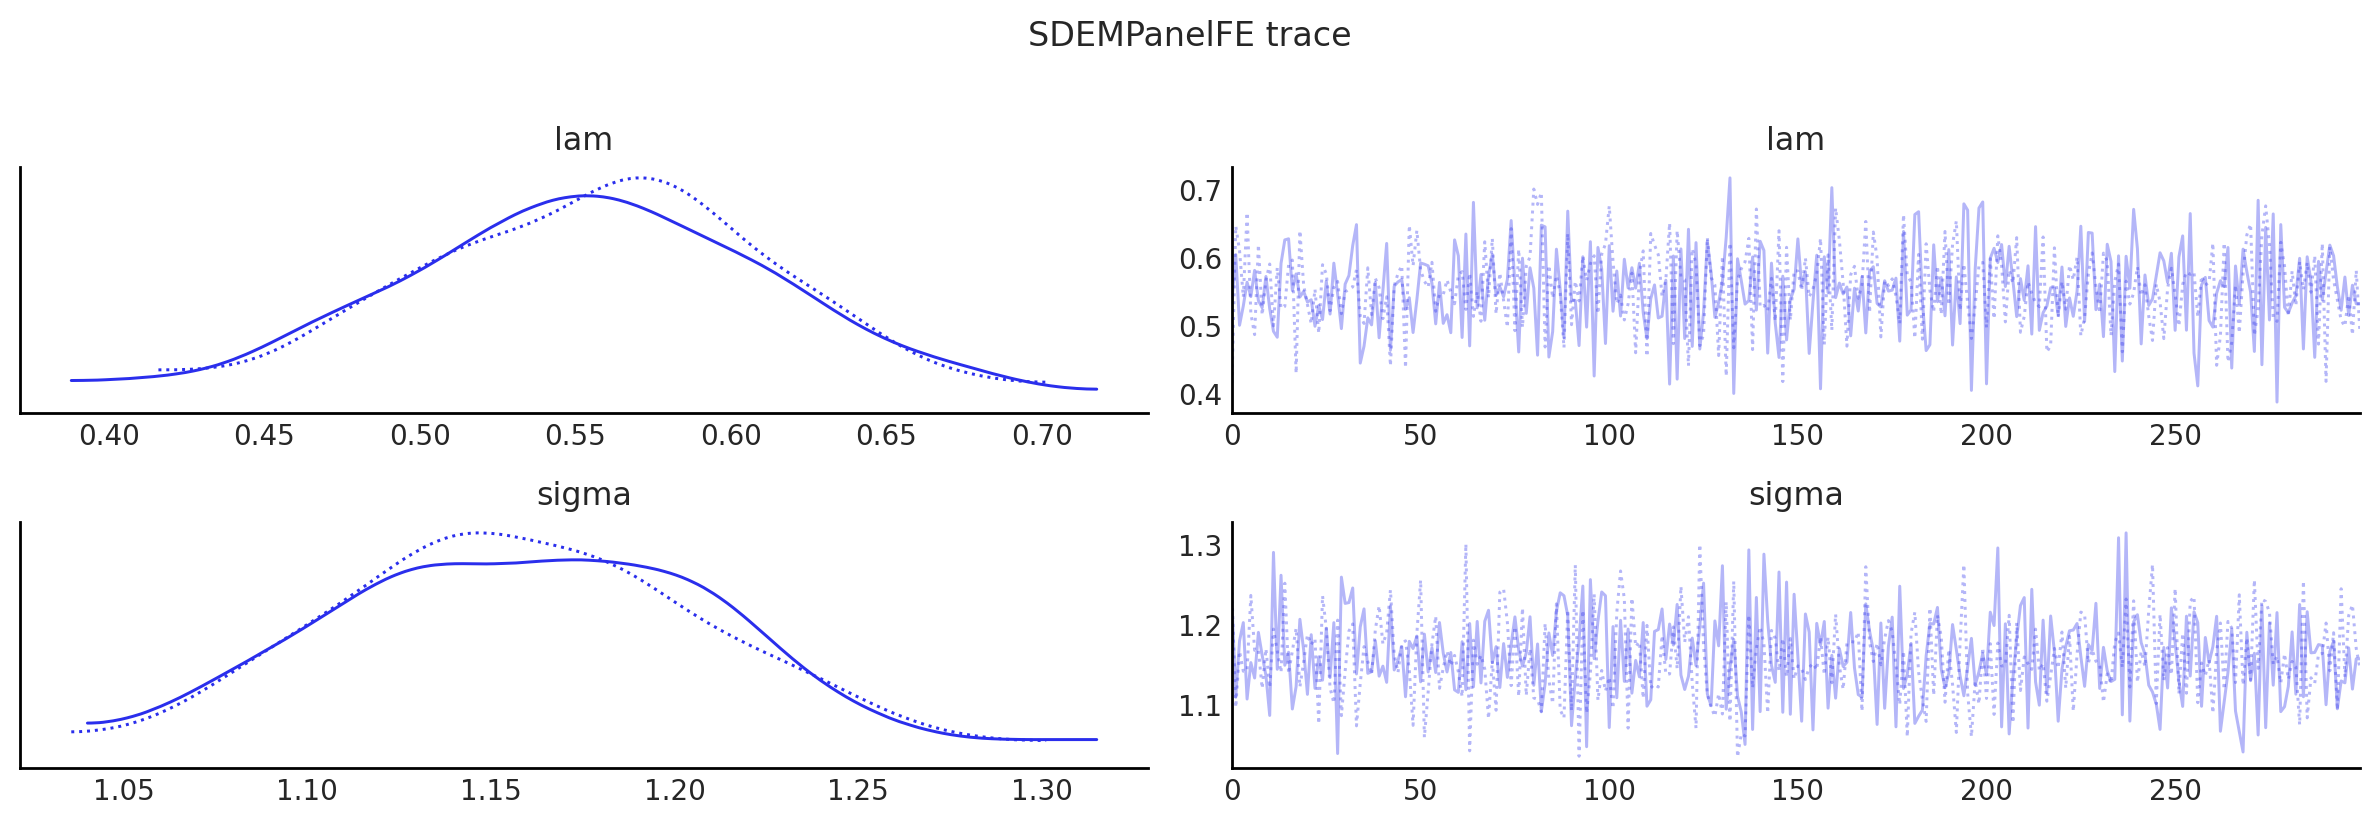

In [17]:
sdem_panel, idata_sdem, summary_sdem, effects_sdem = fit_panel_model(
    SDEMPanelFE, formula, panel, W, model=3
)
display(summary_sdem)
display(effects_sdem)
display(diagnostics_table(idata_sdem, ["lam", "beta", "sigma"]))
show_trace(idata_sdem, ["lam", "sigma"], "SDEMPanelFE trace")

## Random-Effects Panel Models

The random-effects models replace deterministic unit fixed effects with latent unit intercepts $\alpha_i \sim N(0, \sigma_\alpha^2)$. That lets the notebook estimate the variance of unit heterogeneity directly and compare FE and RE behavior on the same synthetic balanced panel.

### Fit: OLSPanelRE

In [ ]:
ols_panel_re, idata_ols_re, summary_ols_re, effects_ols_re = fit_panel_model(
    OLSPanelRE, formula, panel, W, model=0
)
display(summary_ols_re)
display(effects_ols_re)
display(diagnostics_table(idata_ols_re, ["beta", "sigma", "sigma_alpha"]))
show_trace(idata_ols_re, ["sigma", "sigma_alpha"], "OLSPanelRE trace")

### Fit: SARPanelRE

In [ ]:
sar_panel_re, idata_sar_re, summary_sar_re, effects_sar_re = fit_panel_model(
    SARPanelRE, formula, panel, W, model=0
)
display(summary_sar_re)
display(effects_sar_re)
display(diagnostics_table(idata_sar_re, ["rho", "beta", "sigma", "sigma_alpha"]))
show_trace(idata_sar_re, ["rho", "sigma", "sigma_alpha"], "SARPanelRE trace")

### Fit: SEMPanelRE

In [ ]:
sem_panel_re, idata_sem_re, summary_sem_re, effects_sem_re = fit_panel_model(
    SEMPanelRE, formula, panel, W, model=0
)
display(summary_sem_re)
display(effects_sem_re)
display(diagnostics_table(idata_sem_re, ["lam", "beta", "sigma", "sigma_alpha"]))
show_trace(idata_sem_re, ["lam", "sigma", "sigma_alpha"], "SEMPanelRE trace")

## MATLAB-Style Diagnostics Across FE and RE Models

In [ ]:
panel_models = {
    "OLSPanelFE": ols_panel,
    "SARPanelFE": sar_panel,
    "SEMPanelFE": sem_panel,
    "SDMPanelFE": sdm_panel,
    "SDEMPanelFE": sdem_panel,
    "OLSPanelRE": ols_panel_re,
    "SARPanelRE": sar_panel_re,
    "SEMPanelRE": sem_panel_re,
}

rows = []
for name, m in panel_models.items():
    het = m.heteroskedasticity_diagnostics(arch_lags=[1, 2, 4])
    ac = m.autocorrelation_diagnostics(lags=[1, 2, 4])
    out = m.outlier_diagnostics()
    pdiag = m.panel_diagnostics()

    bp = het["bpagan"]
    arch = het["arch"]
    cd = pdiag["pesaran_cd"]

    rows.append({
        "model": name,
        "bpagan_p": float(bp["prob"]),
        "arch_lag4_p": float(arch["pval"][-1]),
        "lb_lag4_p": float(ac["pval"][-1]),
        "pesaran_cd": float(cd["cd"]),
        "pesaran_cd_p": float(cd["pval"]),
        "n_leverage_flags": int(len(out["leverage_idx"])),
        "n_rstudent_flags": int(len(out["rstudent_idx"])),
        "n_dffit_flags": int(len(out["dffit_idx"])),
        "n_dfbeta_flags": int(out["dfbeta_idx"].shape[0]),
    })

diag_panel_table = pd.DataFrame(rows).sort_values("model").reset_index(drop=True)
display(diag_panel_table)

/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics.py:105: RuntimeWarning: invalid value encountered in sqrt
  denom = np.sqrt(np.outer(one_minus_h, diag_xtxi))
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics.py:105: RuntimeWarning: invalid value encountered in sqrt
  denom = np.sqrt(np.outer(one_minus_h, diag_xtxi))
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics.py:105: RuntimeWarning: invalid value encountered in sqrt
  denom = np.sqrt(np.outer(one_minus_h, diag_xtxi))
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics.py:105: RuntimeWarning: invalid value encountered in sqrt
  denom = np.sqrt(np.outer(one_minus_h, diag_xtxi))
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics.py:105: RuntimeWarning: invalid value encountered in sqrt
  denom = np.sqrt(np.outer(one_minus_h, diag_xtxi))


,model,bpagan_p,arch_lag4_p,lb_lag4_p,pesaran_cd,pesaran_cd_p,n_leverage_flags,n_rstudent_flags,n_dffit_flags,n_dfbeta_flags
0,OLSPanelFE,0.893006,2.378711e-07,0.000934,-1.218144,0.223169,0,15,3,21
1,SARPanelFE,0.905954,2.676572e-02,0.000455,-1.196328,0.231568,0,13,3,22
2,SDEMPanelFE,0.853628,4.896134e-07,0.000992,-1.199432,0.230360,0,15,3,20
3,SDMPanelFE,0.888865,3.421890e-02,0.000295,-1.182344,0.237069,0,12,3,22
4,SEMPanelFE,0.854663,5.090466e-07,0.000960,-1.201617,0.229512,0,15,3,20


## Model Comparison (WAIC and LOO) Across FE and RE Models

In [ ]:
idata_dict = {
    "OLSPanelFE": idata_ols,
    "SARPanelFE": idata_sar,
    "SEMPanelFE": idata_sem,
    "SDMPanelFE": idata_sdm,
    "SDEMPanelFE": idata_sdem,
    "OLSPanelRE": idata_ols_re,
    "SARPanelRE": idata_sar_re,
    "SEMPanelRE": idata_sem_re,
}


def _has_loglik(idata):
    if "log_likelihood" not in idata.groups():
        return False
    return len(list(idata.log_likelihood.data_vars)) > 0


valid_for_compare = {name: idata for name, idata in idata_dict.items() if _has_loglik(idata)}
missing_loglik = [name for name, idata in idata_dict.items() if not _has_loglik(idata)]

if missing_loglik:
    print("Skipped (no log_likelihood group):", ", ".join(missing_loglik))

if len(valid_for_compare) < 2:
    print("Need at least two models with valid log_likelihood for WAIC/LOO compare.")
else:
    for ic in ("waic", "loo"):
        try:
            cmp = az.compare(valid_for_compare, ic=ic, method="BB-pseudo-BMA")
            print(f"{ic.upper()} comparison")
            display(cmp)
        except Exception as e:
            print(f"{ic.upper()} comparison not available: {type(e).__name__}: {e}")

# Always provide per-model IC attempts so the cell remains informative.
rows = []
for name, idata in idata_dict.items():
    row = {"model": name}

    try:
        waic_res = az.waic(idata)
        row["elpd_waic"] = float(waic_res.elpd_waic)
        row["p_waic"] = float(waic_res.p_waic)
    except Exception as e:
        row["elpd_waic"] = np.nan
        row["p_waic"] = np.nan
        row["waic_error"] = str(e).split("\n", 1)[0]

    try:
        loo_res = az.loo(idata)
        row["elpd_loo"] = float(loo_res.elpd_loo)
        row["p_loo"] = float(loo_res.p_loo)
    except Exception as e:
        row["elpd_loo"] = np.nan
        row["p_loo"] = np.nan
        row["loo_error"] = str(e).split("\n", 1)[0]

    rows.append(row)

ic_table = pd.DataFrame(rows).sort_values("model").reset_index(drop=True)
display(ic_table)

Skipped (no log_likelihood group): SEMPanelFE, SDEMPanelFE
WAIC comparison


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
SARPanelFE,0,-420.545207,2.858871,0.000000,7.991733e-01,11.061966,0.000000,False,log
SDMPanelFE,1,-422.024276,4.404397,1.479069,2.008267e-01,11.066034,0.615467,False,log
OLSPanelFE,2,-461.298978,2.627491,40.753771,1.236136e-11,14.825098,7.552555,False,log


LOO comparison


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
SARPanelFE,0,-420.564448,2.878112,0.000000,7.983644e-01,11.460213,0.000000,False,log
SDMPanelFE,1,-422.047478,4.427599,1.483030,2.016356e-01,11.433160,0.615983,False,log
OLSPanelFE,2,-461.326766,2.655279,40.762318,2.555208e-11,15.472804,7.556263,False,log


,model,elpd_waic,p_waic,elpd_loo,p_loo,waic_error,loo_error
0,OLSPanelFE,-461.298978,2.627491,-461.326766,2.655279,NaN,NaN
1,SARPanelFE,-420.545207,2.858871,-420.564448,2.878112,NaN,NaN
2,SDEMPanelFE,NaN,NaN,NaN,NaN,log likelihood not found in inference data object,log likelihood not found in inference data object
3,SDMPanelFE,-422.024276,4.404397,-422.047478,4.427599,NaN,NaN
4,SEMPanelFE,NaN,NaN,NaN,NaN,log likelihood not found in inference data object,log likelihood not found in inference data object


## Notes

- This notebook uses modest draw counts for speed. For real analyses, increase `draws` and `tune`.
- If you see divergences or tree-depth warnings, increase `target_accept` (for example 0.95-0.99).
- For production inference, validate sensitivity to FE specification (`model=0/1/2/3`) and priors.